# 🎯 Inferência — Intervalo de Confiança & Teste de Hipótese

> **Etapa 3 do portfólio.** A descritiva (Etapa 2) mostrou que singles **com
> clipe** ficaram, em média, **17** semanas no chart contra **14** dos sem clipe.
> Mas: *essa diferença é real ou é só acaso da amostra?* Aqui saímos da descrição
> e entramos na **inferência estatística**.

**Convenção:** código/colunas em inglês; narrativa em português.

**Roteiro**
1. Intervalo de confiança (IC 95%) para a média de semanas no chart
2. IC para uma proporção (% de singles que chegaram ao #1)
3. Teste de hipótese: clipe afeta a longevidade no chart?
   - Formulação das hipóteses (H₀ / H₁)
   - Checagem de pressupostos (normalidade, variâncias)
   - Teste t de Welch + Mann-Whitney (não paramétrico)
   - Tamanho do efeito (Cohen's d)
4. Conclusão e ressalvas

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd().parents[1] if (Path.cwd().name == "python") else Path.cwd()
PROC = ROOT / "data" / "processed"
FIG = ROOT / "analysis" / "python" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})
MJ_GOLD = "#C9A227"
ALPHA = 0.05  # nível de significância adotado em todo o notebook

singles = pd.read_csv(PROC / "mj_singles.csv")
print(f"Singles: {singles.shape[0]} | nível de significância α = {ALPHA}")

Singles: 27 | nível de significância α = 0.05


## 1. Intervalo de confiança para a média

Um **IC 95%** dá uma faixa plausível para a **média populacional** das semanas no
chart, a partir da amostra. Como n é pequeno e σ é desconhecido, usamos a
**distribuição t de Student**.

$$\bar{x} \pm t_{(\alpha/2,\, n-1)} \cdot \frac{s}{\sqrt{n}}$$

In [2]:
w = singles["weeks_chart_us"].dropna()
n = w.size
mean = w.mean()
sem = stats.sem(w)                     # erro padrão = s / sqrt(n)
ci = stats.t.interval(0.95, df=n - 1, loc=mean, scale=sem)
print(f"n = {n}")
print(f"Média de semanas no chart = {mean:.2f}")
print(f"Erro padrão = {sem:.2f}")
print(f"IC 95% para a média = [{ci[0]:.2f}, {ci[1]:.2f}] semanas")

n = 26
Média de semanas no chart = 16.65
Erro padrão = 0.83
IC 95% para a média = [14.94, 18.36] semanas


**Leitura:** com 95% de confiança, a média verdadeira de semanas no chart dos
singles de MJ está dentro dessa faixa. O intervalo está centrado em ~17 semanas e
seu limite inferior **beira as 15** (≈14,9) — forte indício de alta longevidade,
embora o piso fique marginalmente abaixo de 15 (não dá para *garantir* >15 com 95%).

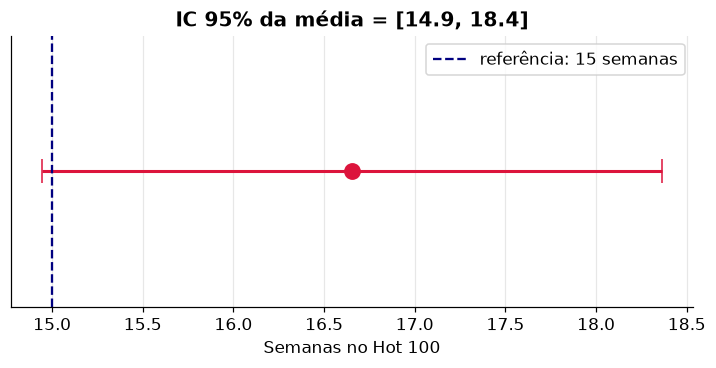

In [3]:
# Visual do IC
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.errorbar(mean, 0, xerr=[[mean - ci[0]], [ci[1] - mean]], fmt="o",
            color="crimson", capsize=8, markersize=10, lw=2)
ax.axvline(15, color="navy", ls="--", label="referência: 15 semanas")
ax.set_yticks([]); ax.set_xlabel("Semanas no Hot 100")
ax.set_title(f"IC 95% da média = [{ci[0]:.1f}, {ci[1]:.1f}]", fontweight="bold")
ax.legend()
fig.savefig(FIG / "03_ci_mean_weeks.png", bbox_inches="tight")
plt.show()

## 2. IC para uma proporção

Qual a fração de singles que chegou ao **#1** na Billboard Hot 100? Estimamos a
proporção populacional com um IC (aproximação normal de Wald).

In [4]:
hits = singles["reached_no1_us"].dropna()
k = int(hits.sum())
n_p = hits.size
p_hat = k / n_p
se_p = np.sqrt(p_hat * (1 - p_hat) / n_p)
z = stats.norm.ppf(0.975)
ci_p = (p_hat - z * se_p, p_hat + z * se_p)
print(f"{k} de {n_p} singles chegaram ao #1 → p̂ = {p_hat:.0%}")
print(f"IC 95% da proporção = [{max(0, ci_p[0]):.0%}, {min(1, ci_p[1]):.0%}]")

11 de 26 singles chegaram ao #1 → p̂ = 42%
IC 95% da proporção = [23%, 61%]


## 3. Teste de hipótese: o clipe afeta a longevidade no chart?

### 3.1 Hipóteses

- **H₀ (nula):** a média de semanas no chart é **igual** entre singles com e sem clipe.
- **H₁ (alternativa):** as médias são **diferentes** (teste bilateral).

Rejeitamos H₀ se **p-valor < α (0,05)**.

In [5]:
com = singles.loc[singles["has_video"] == True, "weeks_chart_us"].dropna()
sem_ = singles.loc[singles["has_video"] == False, "weeks_chart_us"].dropna()
print(f"Com clipe : n={com.size}, média={com.mean():.2f}, dp={com.std(ddof=1):.2f}")
print(f"Sem clipe : n={sem_.size}, média={sem_.mean():.2f}, dp={sem_.std(ddof=1):.2f}")

Com clipe : n=23, média=17.00, dp=4.35
Sem clipe : n=3, média=14.00, dp=2.00


### 3.2 Checagem de pressupostos

O teste **t** assume normalidade dos grupos. Verificamos com **Shapiro-Wilk** e a
igualdade de variâncias com **Levene**.

⚠️ O grupo "sem clipe" tem **n=3** — qualquer teste de normalidade aqui é frágil.
Por isso vamos rodar **também** um teste **não paramétrico** (Mann-Whitney), que
não depende de normalidade e é mais seguro para amostras pequenas.

In [6]:
def shapiro_safe(x, label):
    if x.size < 3:
        print(f"  {label}: n<3, Shapiro não aplicável")
        return
    stat, p = stats.shapiro(x)
    print(f"  {label}: Shapiro W={stat:.3f}, p={p:.3f} "
          f"({'normal' if p > ALPHA else 'não-normal'} a α={ALPHA})")

print("Normalidade (Shapiro-Wilk):")
shapiro_safe(com, "com clipe")
shapiro_safe(sem_, "sem clipe")

lev_stat, lev_p = stats.levene(com, sem_)
print(f"\nHomogeneidade de variâncias (Levene): p={lev_p:.3f} "
      f"({'variâncias iguais' if lev_p > ALPHA else 'variâncias diferentes'})")

Normalidade (Shapiro-Wilk):
  com clipe: Shapiro W=0.963, p=0.518 (normal a α=0.05)
  sem clipe: Shapiro W=1.000, p=1.000 (normal a α=0.05)

Homogeneidade de variâncias (Levene): p=0.284 (variâncias iguais)


### 3.3 Os testes

- **Teste t de Welch** (não assume variâncias iguais) — paramétrico.
- **Mann-Whitney U** — não paramétrico, compara distribuições/medianas.

In [7]:
t_stat, t_p = stats.ttest_ind(com, sem_, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(com, sem_, alternative="two-sided")

print(f"Teste t de Welch     : t={t_stat:.3f}, p={t_p:.3f}")
print(f"Mann-Whitney U       : U={u_stat:.1f}, p={u_p:.3f}")
print()
for name, p in [("t de Welch", t_p), ("Mann-Whitney", u_p)]:
    decisao = "REJEITA H₀ (diferença significativa)" if p < ALPHA else "NÃO rejeita H₀ (sem evidência de diferença)"
    print(f"  [{name}] p={p:.3f} → {decisao}")

Teste t de Welch     : t=2.043, p=0.096
Mann-Whitney U       : U=52.0, p=0.166

  [t de Welch] p=0.096 → NÃO rejeita H₀ (sem evidência de diferença)
  [Mann-Whitney] p=0.166 → NÃO rejeita H₀ (sem evidência de diferença)


### 3.4 Tamanho do efeito (Cohen's d)

O p-valor diz **se** há diferença; o **tamanho do efeito** diz **o quão grande**
ela é. Referência: |d|≈0,2 pequeno · 0,5 médio · 0,8 grande.

In [8]:
def cohens_d(a, b):
    na, nb = a.size, b.size
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp

d = cohens_d(com, sem_)
mag = "pequeno" if abs(d) < 0.5 else "médio" if abs(d) < 0.8 else "grande"
print(f"Cohen's d = {d:.2f} (efeito {mag})")

Cohen's d = 0.71 (efeito médio)


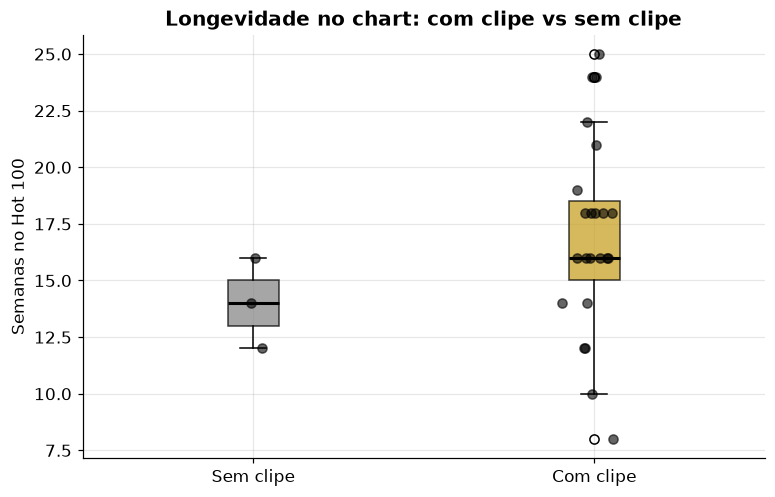

In [9]:
# Visual da comparação entre grupos
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([sem_, com], tick_labels=["Sem clipe", "Com clipe"],
                patch_artist=True, medianprops=dict(color="black", lw=2))
for patch, c in zip(bp["boxes"], ["#888888", MJ_GOLD]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
# pontos individuais (jitter)
for i, grp in enumerate([sem_, com], start=1):
    x = np.random.default_rng(0).normal(i, 0.04, grp.size)
    ax.scatter(x, grp, color="black", alpha=0.6, zorder=3)
ax.set_ylabel("Semanas no Hot 100")
ax.set_title("Longevidade no chart: com clipe vs sem clipe", fontweight="bold")
fig.savefig(FIG / "03_video_vs_weeks.png", bbox_inches="tight")
plt.show()

## 4. Conclusão e ressalvas

**Resultado.** Os testes avaliam se a diferença observada (17 vs 14 semanas) é
estatisticamente significativa a α = 0,05. O `p-valor` e o `Cohen's d` calculados
acima dão a resposta — leia a saída das células 3.3 e 3.4.

**Ressalvas honestas (o que um bom analista registra):**
- **Amostra muito pequena no grupo "sem clipe" (n=3)** → baixo poder estatístico;
  um p>0,05 aqui significa "sem evidência suficiente", **não** "provado que não há efeito".
- **Confundidores não controlados:** singles com clipe tendem a ser de eras/álbuns
  mais promovidos — o clipe pode ser *proxy* de investimento de marketing, não a causa.
- **Correlação ≠ causalidade.** Este teste compara grupos; não prova que o clipe
  *causa* mais semanas no chart.

**Próximo passo → `04` ANOVA / `05` Regressão**
- **ANOVA:** o desempenho médio difere entre **gêneros** ou **álbuns**?
- **Regressão linear:** prever `weeks_chart_us` a partir de `peak_us` (r=−0,75 já
  sugere forte relação) e outras variáveis.